# Probability of Nth Recall

> Examine which study positions are recalled at each output position.

The probability of nth recall (PNR) examines which study positions are recalled at each output position. For example, the first-recall PNR shows that the last few items studied (recency positions) are most likely to be recalled first, reflecting the strong recency effect in immediate free recall.

The conditional variant divides the number of times a position was actually recalled at output position $n$ by the number of times it was still available (not yet recalled), giving a probability conditioned on availability.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.pnr import plot_pnr
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
query_recall_position = 0
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

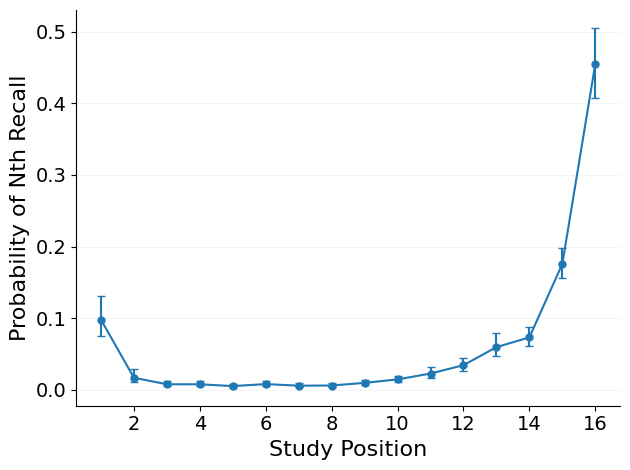

In [4]:
plot_pnr(data, trial_mask, query_recall_position=query_recall_position, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study position and the y-axis shows the probability of recalling that position at the queried output position. Key patterns:

- **First-recall PNR** (`query_recall_position=0`): typically shows a strong recency gradient — the last items studied are most likely to be recalled first.
- **Later output positions**: the recency advantage diminishes and primacy effects may emerge as participants work through their recall sequence.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `query_recall_position` — 0-based output position to query. 0 = first recall, 1 = second, etc.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.
